<a href="https://colab.research.google.com/github/NobodydeBunny/Cat_Dog_breed_classifire_AI_model/blob/main/Dogs_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from collections import defaultdict, Counter
import random

In [2]:
(dataset, info) = tfds.load("oxford_iiit_pet",
                            with_info=True,
                            as_supervised=True)

train_ds = dataset['train']
test_ds = dataset['test']
class_names = info.features['label'].names

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.PJSCL1_4.0.0/oxford_iiit_pet-train.tfrecord*...…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.PJSCL1_4.0.0/oxford_iiit_pet-test.tfrecord*...:…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.


In [3]:
cat_labels = tf.constant(
    [i for i, name in enumerate(class_names) if name[0].isupper()],
    dtype=tf.int64
)

def is_cat(image, label):
    return tf.reduce_any(tf.equal(cat_labels, label))

train_ds = train_ds.filter(is_cat)
test_ds = test_ds.filter(is_cat)

cat_class_names = [class_names[i] for i in cat_labels.numpy()]
NUM_CLASSES = len(cat_class_names)

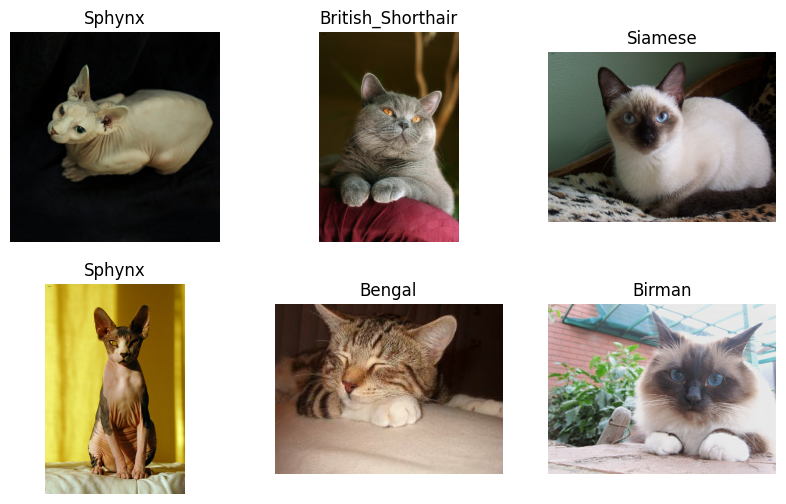

In [4]:
plt.figure(figsize=(10,6))

label_map = {int(original_idx): new_idx for new_idx, original_idx in enumerate(cat_labels.numpy())}

for i, (image, label) in enumerate(train_ds.take(6)):
    plt.subplot(2, 3, i+1)
    plt.imshow(image)
    plt.title(cat_class_names[label_map[int(label.numpy())]])
    plt.axis('off')

plt.show()

In [5]:
IMG_SIZE = 225

all_cats_ds = train_ds.concatenate(test_ds)

class_images = defaultdict(list)

for image, label in all_cats_ds:
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    class_images[int(label.numpy())].append((image, int(label.numpy())))

train_list, val_list, test_list = [], [], []

train_ratio = 0.8
val_ratio = 0.1

for class_idx, images in class_images.items():
    random.shuffle(images)

    total = len(images)
    n_train = int(total * train_ratio)
    n_val = int(n_train * val_ratio)
    n_train -= n_val

    train_list.extend(images[:n_train])
    val_list.extend(images[n_train:n_train+n_val])
    test_list.extend(images[n_train+n_val:])

def make_dataset(data_list):
    images = tf.stack([img for img, _ in data_list])
    labels = tf.constant([lbl for _, lbl in data_list], dtype=tf.int64)
    return tf.data.Dataset.from_tensor_slices((images, labels))

train_ds = make_dataset(train_list)
val_ds   = make_dataset(val_list)
test_ds  = make_dataset(test_list)

print("Train:", len(train_list))
print("Validation:", len(val_list))
print("Test:", len(test_list))

Train: 1709
Validation: 187
Test: 475


In [6]:
BATCH_SIZE = 32

label_table = tf.lookup.StaticHashTable(
    tf.lookup.KeyValueTensorInitializer(
        keys=tf.constant(list(label_map.keys()), dtype=tf.int64),
        values=tf.constant(list(label_map.values()), dtype=tf.int64),
    ),
    default_value=-1
)

def preprocess(image, label):
    label = label_table.lookup(label)
    return image, label

train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
val_ds   = val_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds  = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

train_ds = train_ds.shuffle(len(train_list)).batch(BATCH_SIZE, drop_remainder=False).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.shuffle(len(val_list)).batch(BATCH_SIZE, drop_remainder=False).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE, drop_remainder=False).prefetch(tf.data.AUTOTUNE)

print("Datasets ready.")

Datasets ready.


Image shape: (32, 225, 225, 3)
Label values: [ 8  0  8  6  8 11 11  2  5  2  1  9 10  9  3  9  3 11  3  4 11  2  0  1
 11  9  1 10  8  8  8  2]


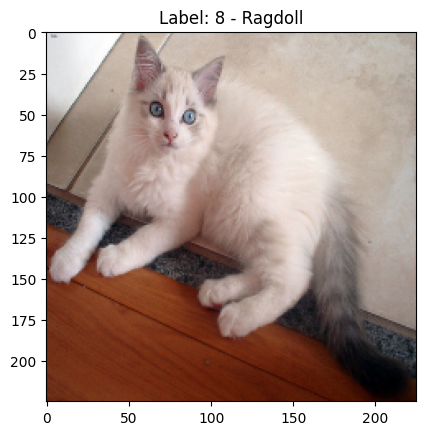

In [7]:
# Check a few samples from the dataset
for images, labels in train_ds.take(1):
    print("Image shape:", images.shape)      # Should be (32,225,225,3)
    print("Label values:", labels.numpy())   # Should be integers 0–11
    # Display one image
    import matplotlib.pyplot as plt
    plt.imshow(images[0])
    plt.title(f"Label: {labels[0].numpy()} - {cat_class_names[labels[0].numpy()]}")
    plt.show()

In [8]:
def show_class_distribution(dataset, name):
    counter = Counter()

    for _, labels in dataset.unbatch():
        counter[int(labels.numpy())] += 1

    print(f"\n{name} Distribution")
    total = sum(counter.values())
    for cls, count in sorted(counter.items()):
        print(f"{cat_class_names[cls]:<25} : {count}")
    print("Total:", total)

show_class_distribution(train_ds, "Train")
show_class_distribution(val_ds, "Validation")
show_class_distribution(test_ds, "Test")


Train Distribution
Abyssinian                : 143
Bengal                    : 144
Birman                    : 144
Bombay                    : 133
British_Shorthair         : 144
Egyptian_Mau              : 137
Maine_Coon                : 144
Persian                   : 144
Ragdoll                   : 144
Russian_Blue              : 144
Siamese                   : 144
Sphynx                    : 144
Total: 1709

Validation Distribution
Abyssinian                : 15
Bengal                    : 16
Birman                    : 16
Bombay                    : 14
British_Shorthair         : 16
Egyptian_Mau              : 15
Maine_Coon                : 16
Persian                   : 16
Ragdoll                   : 16
Russian_Blue              : 16
Siamese                   : 15
Sphynx                    : 16
Total: 187

Test Distribution
Abyssinian                : 40
Bengal                    : 40
Birman                    : 40
Bombay                    : 37
British_Shorthair         : 40
Eg

In [9]:
for x, y in train_ds.take(1):
    print(x.shape, y.shape)
    print(tf.reduce_min(x), tf.reduce_max(x))

(32, 225, 225, 3) (32,)
tf.Tensor(0.0, shape=(), dtype=float32) tf.Tensor(1.0, shape=(), dtype=float32)


In [10]:
for x, y in val_ds.take(1):
    print(tf.reduce_min(x), tf.reduce_max(x))

tf.Tensor(0.0, shape=(), dtype=float32) tf.Tensor(1.0, shape=(), dtype=float32)


In [11]:
for img, label in val_ds.take(5):
    print(label.numpy())

[ 5 11  8  0  3 10  0  7  3  6  6  8  8  2  6  7  9  2  5  7  0 11 10  3
 11 10  1  0  2  2  8 11]
[ 1  6  8  5  6  7  5  8  9  0 11  0  6  1  7  0  0  3  0  5 10  3  5  3
  8  6  6  7  1  4  2  8]
[ 9  1  4  4  4 11  6  6  7  9  9  2  6  4  3  0  7  0  9 10 11  2  4  8
  8  2  7  4  6  0  8  5]
[ 3  3  4  7  5  3 11  9  0  4  2 10  4  3  4  5  3 10 11  6  5  9  9  1
 10  7  1 11  5  3  2  9]
[ 2  6  8  9  6  2  9  8  9 11  5  4  1  9  1 10 10  7  1  2  1  1  8  1
  7  4  2  1  5 10  5  7]


In [12]:
INIT_LR = 1e-2                # higher initial LR
MIN_LR = 1e-4
TOTAL_EPOCHS = 100
BATCH_SIZE = 32
WEIGHT_DECAY = 1e-5           # reduced weight decay
PATIENCE = 10
WARMUP_EPOCHS = 5

# Cosine decay after warmup
total_train_steps = (len(train_list) // BATCH_SIZE) * TOTAL_EPOCHS
warmup_steps = (len(train_list) // BATCH_SIZE) * WARMUP_EPOCHS

def lr_scheduler(epoch):
    if epoch < WARMUP_EPOCHS:
        # linear warmup
        return INIT_LR * (epoch + 1) / WARMUP_EPOCHS
    else:
        # cosine decay after warmup
        progress = (epoch - WARMUP_EPOCHS) / (TOTAL_EPOCHS - WARMUP_EPOCHS)
        return MIN_LR + 0.5 * (INIT_LR - MIN_LR) * (1 + tf.math.cos(tf.constant(3.14159) * progress))

In [13]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [14]:
model = tf.keras.Sequential([

    data_augmentation,

    # First Convolutional Block
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.25),

    # Second Convolutional Block
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.25),

    # Third Convolutional Block
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.25),

    # Fourth Convolutional Block
    tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.25),

    # Fifth Convolutional Block
    tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
optimizer = tf.keras.optimizers.AdamW(
    learning_rate=INIT_LR,           # we'll override with callback
    weight_decay=WEIGHT_DECAY,
    clipnorm=1.0                     # gradient clipping
)
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=PATIENCE,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True
    )
]

In [17]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=TOTAL_EPOCHS,
    callbacks=callbacks
)

Epoch 1/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 47s 434ms/step - accuracy: 0.0905 - loss: 3.7374 - val_accuracy: 0.0856 - val_loss: 1982.8842
Epoch 2/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 19s 348ms/step - accuracy: 0.1004 - loss: 3.0013 - val_accuracy: 0.0749 - val_loss: 144.8327
Epoch 3/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 20s 360ms/step - accuracy: 0.1012 - loss: 2.8243 - val_accuracy: 0.1230 - val_loss: 6.2779
Epoch 4/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 20s 361ms/step - accuracy: 0.1224 - loss: 2.6920 - val_accuracy: 0.1176 - val_loss: 4.1020
Epoch 5/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 20s 362ms/step - accuracy: 0.1180 - loss: 2.6325 - val_accuracy: 0.1123 - val_loss: 5.2258
Epoch 6/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 21s 374ms/step - accuracy: 0.1576 - loss: 2.5312 - val_accuracy: 0.1283 - val_loss: 2.8373
Epoch 7/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 21s 373ms/step - accuracy: 0.1344 - loss: 2.4541 - val_accuracy: 0.1283 - val_loss: 2.5717
Epoch 8/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 21s 383ms/step - accuracy: 0.1671 - loss: 2.38

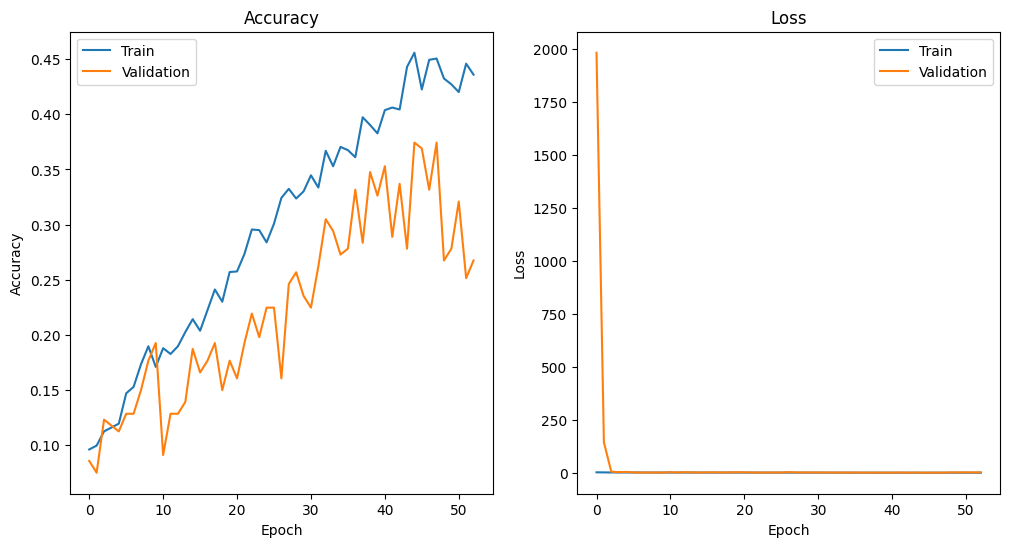

In [18]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [19]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.2883 - loss: 2.1481
Test Loss: 1.7740
Test Accuracy: 0.4295


In [20]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=cat_class_names))

                   precision    recall  f1-score   support

       Abyssinian       0.39      0.28      0.32        40
           Bengal       0.73      0.40      0.52        40
           Birman       0.42      0.35      0.38        40
           Bombay       0.87      0.89      0.88        37
British_Shorthair       0.20      0.03      0.04        40
     Egyptian_Mau       0.32      0.92      0.48        38
       Maine_Coon       0.30      0.42      0.35        40
          Persian       0.40      0.40      0.40        40
          Ragdoll       0.35      0.60      0.44        40
     Russian_Blue       0.55      0.45      0.49        40
          Siamese       0.58      0.38      0.45        40
           Sphynx       0.24      0.10      0.14        40

         accuracy                           0.43       475
        macro avg       0.45      0.43      0.41       475
     weighted avg       0.44      0.43      0.41       475



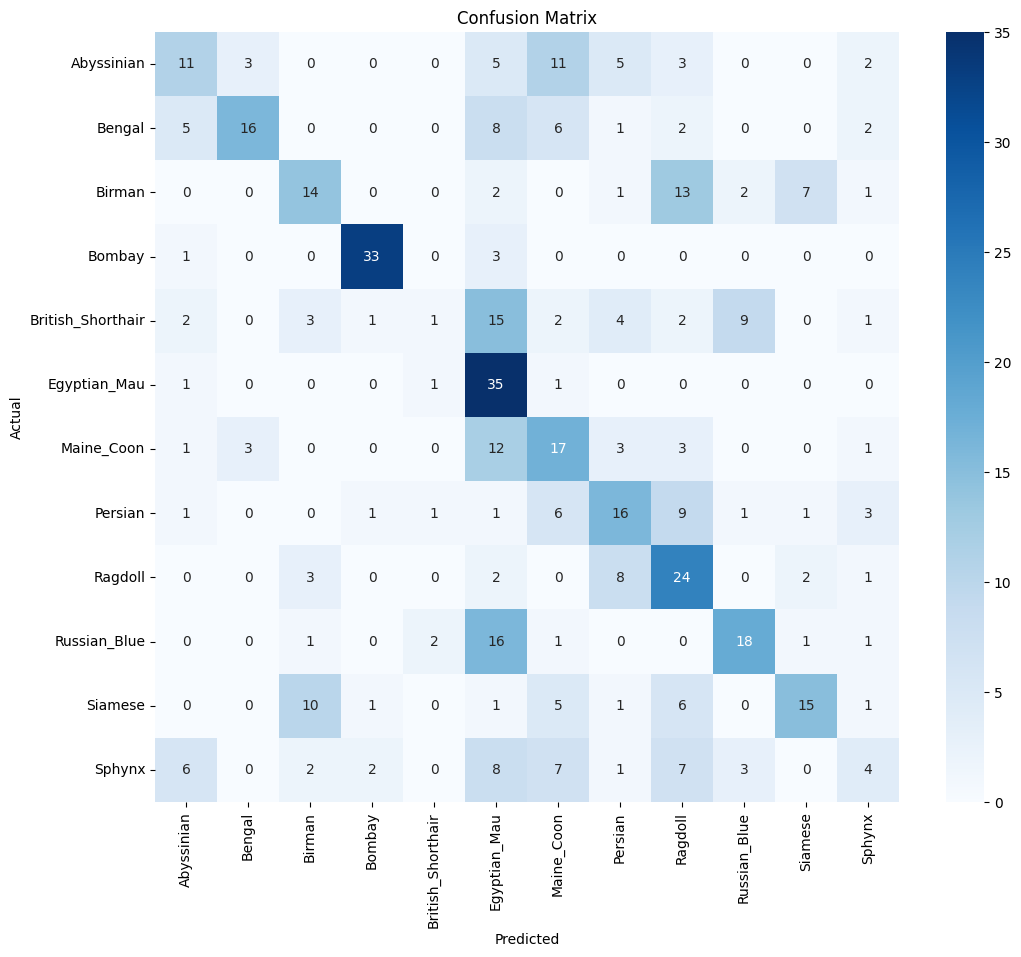

In [21]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cat_class_names,
            yticklabels=cat_class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [22]:
def predict_and_display_random():
    test_list = list(test_ds.unbatch())

    index = random.randint(0, len(test_list) - 1)

    image, label = test_list[index]
    input_img = tf.expand_dims(image, axis=0)

    probs = model.predict(input_img, verbose=0)[0]
    pred_class = np.argmax(probs)

    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.imshow(image)
    plt.title(f"True: {cat_class_names[label.numpy()]}")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.barh(cat_class_names, probs*100)
    plt.xlim(0, 100)
    plt.title(f"Predicted: {cat_class_names[pred_class]}")
    plt.show()

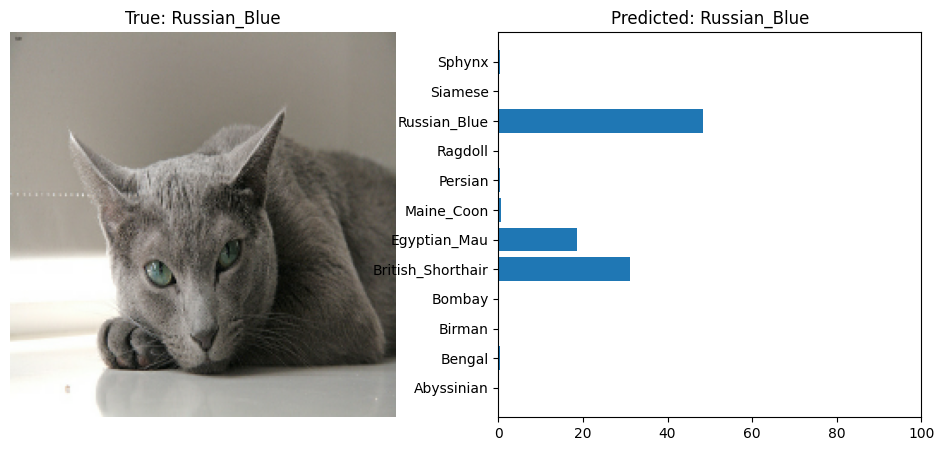

In [28]:
predict_and_display_random()

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [25]:
model.save("/content/drive/MyDrive/Colab Notebooks/cat_breed_model_v9.keras")
print("Model saved successfully.")

Model saved successfully.
